# 二维最优分箱（OptimalBinning2D）示例

本示例展示二维最优分箱的完整流程：先分别对两个特征预分箱，再将二维平面中的相邻格子合并为最终分箱，并生成标准分箱表、可视化和转换结果。

In [1]:
import os, sys
sys.path.append('../')

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from hscredit.core.binning import OptimalBinning2D

## 1. 加载数据

In [3]:
# 加载真实业务数据
df = pd.read_excel('hscredit_yyp.xlsx')

# 目标列：使用 MOB1>3 作为演示标签
df['target_demo'] = (df['MOB1'] > 3).astype(int)
target = 'target_demo'

# 排除字段
exclude_cols = {'MOB1', 'MOB2', 'target_demo'}
# 仅保留可用于建模的数值列，过滤 ID/编号类字段
id_keywords = {'编', '编号', '号码', 'ID', 'id'}
features = [
    c for c in df.columns
    if c not in exclude_cols
    and pd.api.types.is_numeric_dtype(df[c])
    and not any(kw in c for kw in id_keywords)
]

# 优先选用含 C3 的数值评分列
def pick_feature(cols):
    for c in cols:
        if 'C3' in str(c) or 'c3' in str(c):
            return c
    return cols[0]

feat1 = pick_feature(features)  # 特征1
feat2 = features[1] if len(features) > 1 else features[0]  # 特征2

print(f"样本数: {len(df)}, 坏样本率: {df[target].mean():.2%}")
print(f"特征1: {feat1}")
print(f"特征2: {feat2}")
print(df[[feat1, feat2, 'MOB1', target]].head())

样本数: 970, 坏样本率: 16.70%
特征1: 中智小牛分C3
特征2: CURRENT_DPD
   中智小牛分C3  CURRENT_DPD  MOB1  target_demo
0      NaN            0     0            0
1      NaN            0     0            0
2      NaN            0     0            0
3      NaN            0     0            0
4      NaN            0     0            0


## 2. 拟合 OptimalBinning2D

两个特征的一维分箱数控制初始网格大小，`max_n_bins_2d` 控制相邻格子合并后的最终二维箱数。`monotonic_x` / `monotonic_y` 可分别约束沿两个特征方向的坏样本率趋势。

In [4]:
# 创建二维分箱器：最多 5×5 个预分箱格，最终合并为不超过 6 个二维箱
binner = OptimalBinning2D(
    max_n_bins=5,
    max_n_bins_2d=6,
    monotonic_x='auto',
    monotonic_y='auto',
)

binner.fit(df, y=df[target], features=[feat1, feat2])

print(f"特征1预分箱数: {binner.n_bins_x_}")
print(f"特征2预分箱数: {binner.n_bins_y_}")
print(f"最终二维分箱数: {binner.n_bins_2d_}")
print(f"预分箱网格IV: {binner.iv_grid_:.4f}")
print(f"最终交互IV: {binner.iv_interaction_:.4f}")
print("二维分箱索引矩阵:")
print(binner.solution_)

特征1预分箱数: 4
特征2预分箱数: 3
最终二维分箱数: 9
预分箱网格IV: 1.8792
最终交互IV: 1.8628
二维分箱索引矩阵:
[[0 0 1]
 [0 0 2]
 [3 3 4]
 [5 5 4]
 [6 7 8]]


## 3. 最终二维分箱表与预分箱网格明细

In [5]:
# get_bin_table() 返回合并后的正式二维分箱表，指标由 compute_bin_stats 统一计算
binning_table = binner.get_bin_table()
print("最终二维分箱表:")
display(binning_table)

# get_cross_table() 保留每个预分箱格的明细，并标记其所属的最终二维箱
cross_table = binner.get_cross_table()
print("预分箱网格明细:")
display(cross_table.head())

最终二维分箱表:


,指标名称,指标含义,分箱,分箱标签,样本总数,样本占比,好样本数,坏样本数,好样本占比,坏样本占比,...,指标IV值,LIFT值,坏账改善,风险拒绝比,累积LIFT值,累积坏账改善,累计风险拒绝比,累积好样本数,累积坏样本数,分档KS值
0,中智小牛分C3XCURRENT_DPD,None,0,"[-inf, 663.6) × [0.0, 38.2)",157,0.1619,143,14,0.1770,0.0864,...,1.8629,0.5339,-0.0900,-0.5561,0.5339,-0.0900,-0.5561,143,14,0.0906
1,中智小牛分C3XCURRENT_DPD,None,1,"[-inf, 550.0) × [38.2, +inf)",13,0.0134,2,11,0.0025,0.0679,...,1.8629,5.0665,0.0552,4.1217,0.8805,-0.0254,-0.1448,145,25,0.0251
2,中智小牛分C3XCURRENT_DPD,None,2,"[550.0, 663.6) × [38.2, +inf)",14,0.0144,4,10,0.0050,0.0617,...,1.8629,4.2769,0.0480,3.3249,1.1390,0.0325,0.1715,149,35,0.0316
3,中智小牛分C3XCURRENT_DPD,None,3,"[663.6, 713.0) × [0.0, 38.2)",54,0.0557,51,3,0.0631,0.0185,...,1.8629,0.3326,-0.0393,-0.7067,0.9560,-0.0143,-0.0583,200,38,0.0130
4,中智小牛分C3XCURRENT_DPD,None,4,"[663.6, +inf) × [38.2, +inf)",10,0.0103,4,6,0.0050,0.0370,...,1.8629,3.5926,0.0270,2.6196,1.0623,0.0214,0.0837,204,44,0.0191
5,中智小牛分C3XCURRENT_DPD,None,5,"[713.0, +inf) × [0.0, 38.2)",59,0.0608,57,2,0.0705,0.0123,...,1.8629,0.2030,-0.0516,-0.8486,0.8972,-0.0476,-0.1504,261,46,0.0391
6,中智小牛分C3XCURRENT_DPD,None,6,"缺失值 × [0.0, 38.2)",0,0.0000,0,0,0.0000,0.0000,...,1.8629,0.0000,0.0000,0.0000,0.8972,-0.0476,-0.1504,261,46,0.0391
7,中智小牛分C3XCURRENT_DPD,None,7,"缺失值 × [0.0, 38.2)",506,0.5216,475,31,0.5879,0.1914,...,1.8629,0.3668,-0.6905,-1.3236,0.5671,-2.2417,-2.6746,736,77,0.4356
8,中智小牛分C3XCURRENT_DPD,None,8,"缺失值 × [38.2, +inf)",157,0.1619,72,85,0.0891,0.5247,...,1.8629,3.2417,0.4329,2.6746,1.0000,1.0000,1.0000,808,162,0.0000


预分箱网格明细:


,分箱,分箱标签,特征1名称,特征1分箱,特征1标签,特征2名称,特征2分箱,特征2标签,样本总数,样本占比,...,指标IV值,LIFT值,坏账改善,风险拒绝比,累积LIFT值,累积坏账改善,累计风险拒绝比,累积好样本数,累积坏样本数,分档KS值
0,0,"[-inf, 663.6) × [0.0, 38.2)",中智小牛分C3,0,"[-inf, 550.0)",CURRENT_DPD,0,"[0.0, 38.2)",0,0.0000,...,1.8792,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0,0,0.0000
1,0,"[-inf, 663.6) × [0.0, 38.2)",中智小牛分C3,0,"[-inf, 550.0)",CURRENT_DPD,1,"[0.0, 38.2)",48,0.0495,...,1.8792,0.4990,-0.0261,-0.5271,0.4990,-0.0261,-0.5271,44,4,0.0298
2,1,"[-inf, 550.0) × [38.2, +inf)",中智小牛分C3,0,"[-inf, 550.0)",CURRENT_DPD,2,"[38.2, +inf)",13,0.0134,...,1.8792,5.0665,0.0552,4.1217,1.4724,0.0317,0.5041,46,15,0.0357
3,0,"[-inf, 663.6) × [0.0, 38.2)",中智小牛分C3,1,"[550.0, 663.6)",CURRENT_DPD,0,"[0.0, 38.2)",0,0.0000,...,1.8792,0.0000,0.0000,0.0000,1.4724,0.0317,0.5041,46,15,0.0357
4,0,"[-inf, 663.6) × [0.0, 38.2)",中智小牛分C3,1,"[550.0, 663.6)",CURRENT_DPD,1,"[0.0, 38.2)",109,0.1124,...,1.8792,0.5493,-0.0571,-0.5077,0.8805,-0.0254,-0.1448,145,25,0.0251


## 4. 高风险二维分箱

In [6]:
# 按最终二维箱的坏样本率筛选高风险区域
high_risk = binning_table[
    (binning_table['分箱'] >= 0) & (binning_table['坏样本率'] > 0.35)
]
print("高风险二维分箱（坏样本率 > 35%）:")
display(high_risk[['分箱', '分箱标签', '样本占比', '坏样本率', 'LIFT值']])

高风险二维分箱（坏样本率 > 35%）:


,分箱,分箱标签,样本占比,坏样本率,LIFT值
1,1,"[-inf, 550.0) × [38.2, +inf)",0.0134,0.8462,5.0665
2,2,"[550.0, 663.6) × [38.2, +inf)",0.0144,0.7143,4.2769
4,4,"[663.6, +inf) × [38.2, +inf)",0.0103,0.6000,3.5926
8,8,"缺失值 × [38.2, +inf)",0.1619,0.5414,3.2417


## 5. 最终二维分箱可视化

热力图中的相同指标色块属于同一最终二维箱，黑色粗线表示合并边界，`#编号` 对应分箱表中的 `分箱`。

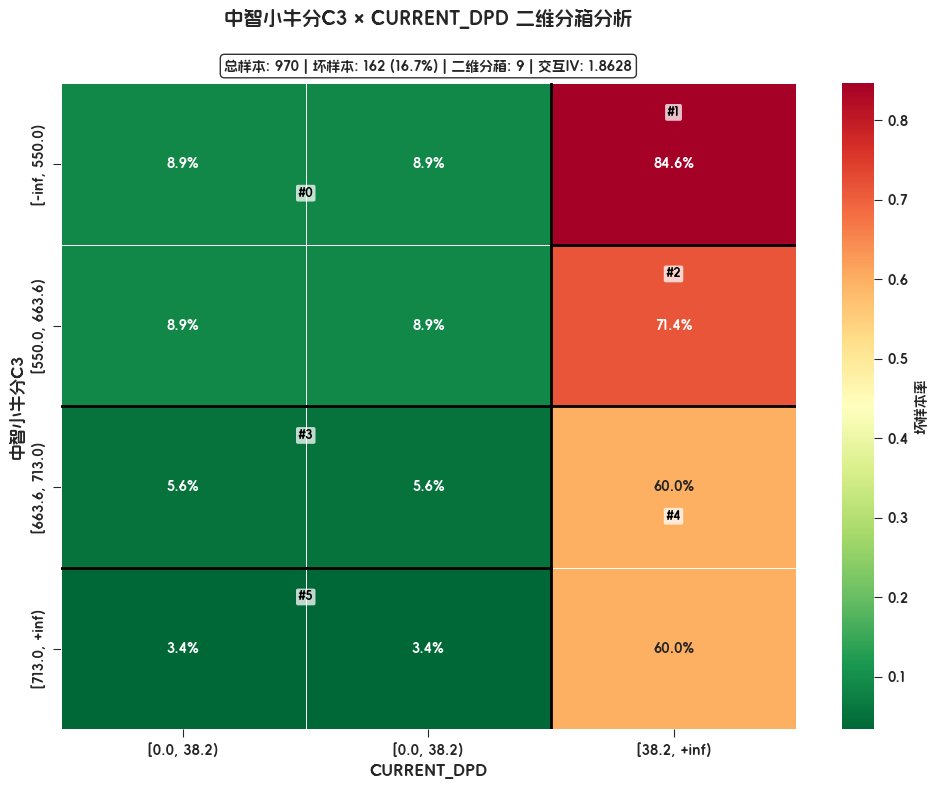

In [7]:
# 绘制坏样本率热力图
fig = binner.plot(metric='bad_rate', figsize=(10, 8))
plt.show()

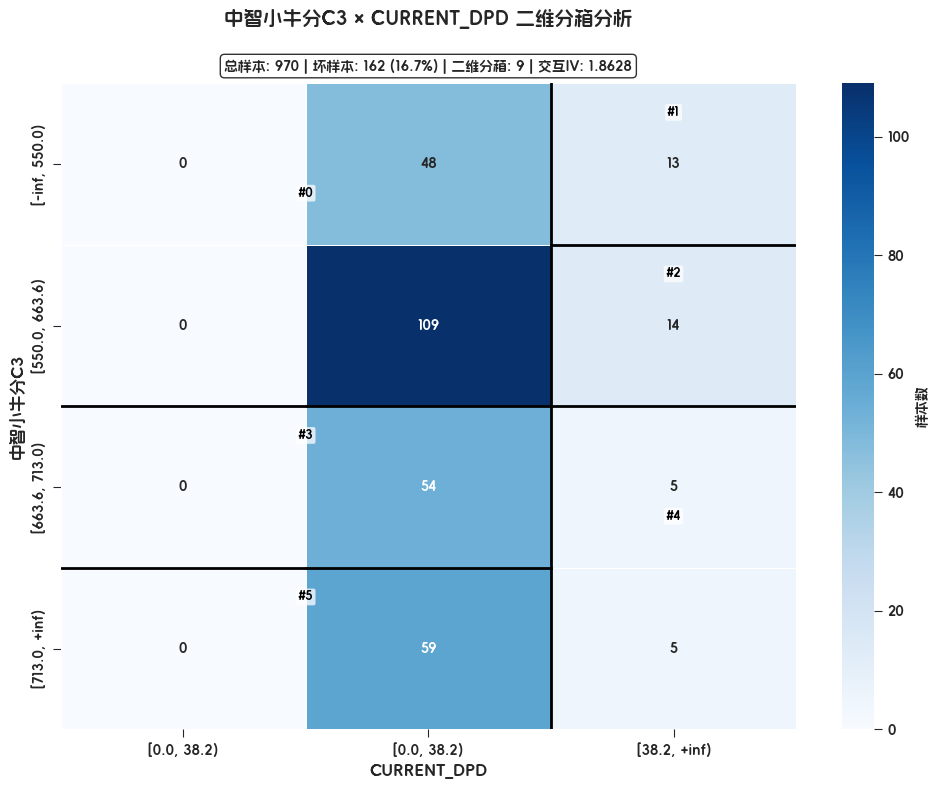

In [8]:
# 绘制样本数热力图
fig = binner.plot(metric='count', fmt='d', figsize=(10, 8))
plt.show()

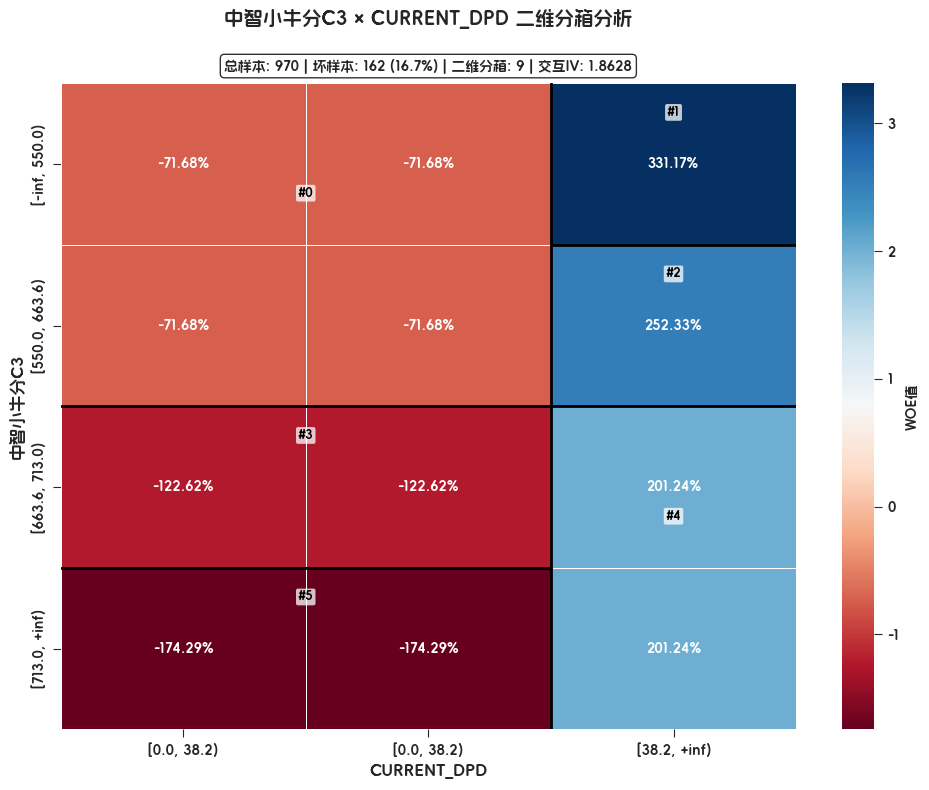

In [9]:
# 绘制 WOE 热力图
fig = binner.plot(metric='woe', figsize=(10, 8))
plt.show()

## 6. 二维联合分析图（bin_2d_plot）

`bin_2d_plot` 在一张图中联合呈现两个变量的交叉分箱分析（3×3 布局），便于一次性查看交互效应：

- **对角两角**：两个特征各自的单变量分箱图（复用 `bin_plot`，与交叉热力图共用坐标系——上方为特征2（纵向），右下为特征1（横向））
- **两条 KS 曲线**：各特征的单变量 KS（复用 `ks_plot`，仅保留 KS 曲线、去掉 ROC）
- **其余 5 格**：两变量分箱交叉指标热力图（样本占比、坏样本率、LIFT、风险拒绝比、坏账改善），均以百分数标注

支持两种输入：已拟合的 `OptimalBinning2D`，或原始 `DataFrame`（内部自动分箱）。

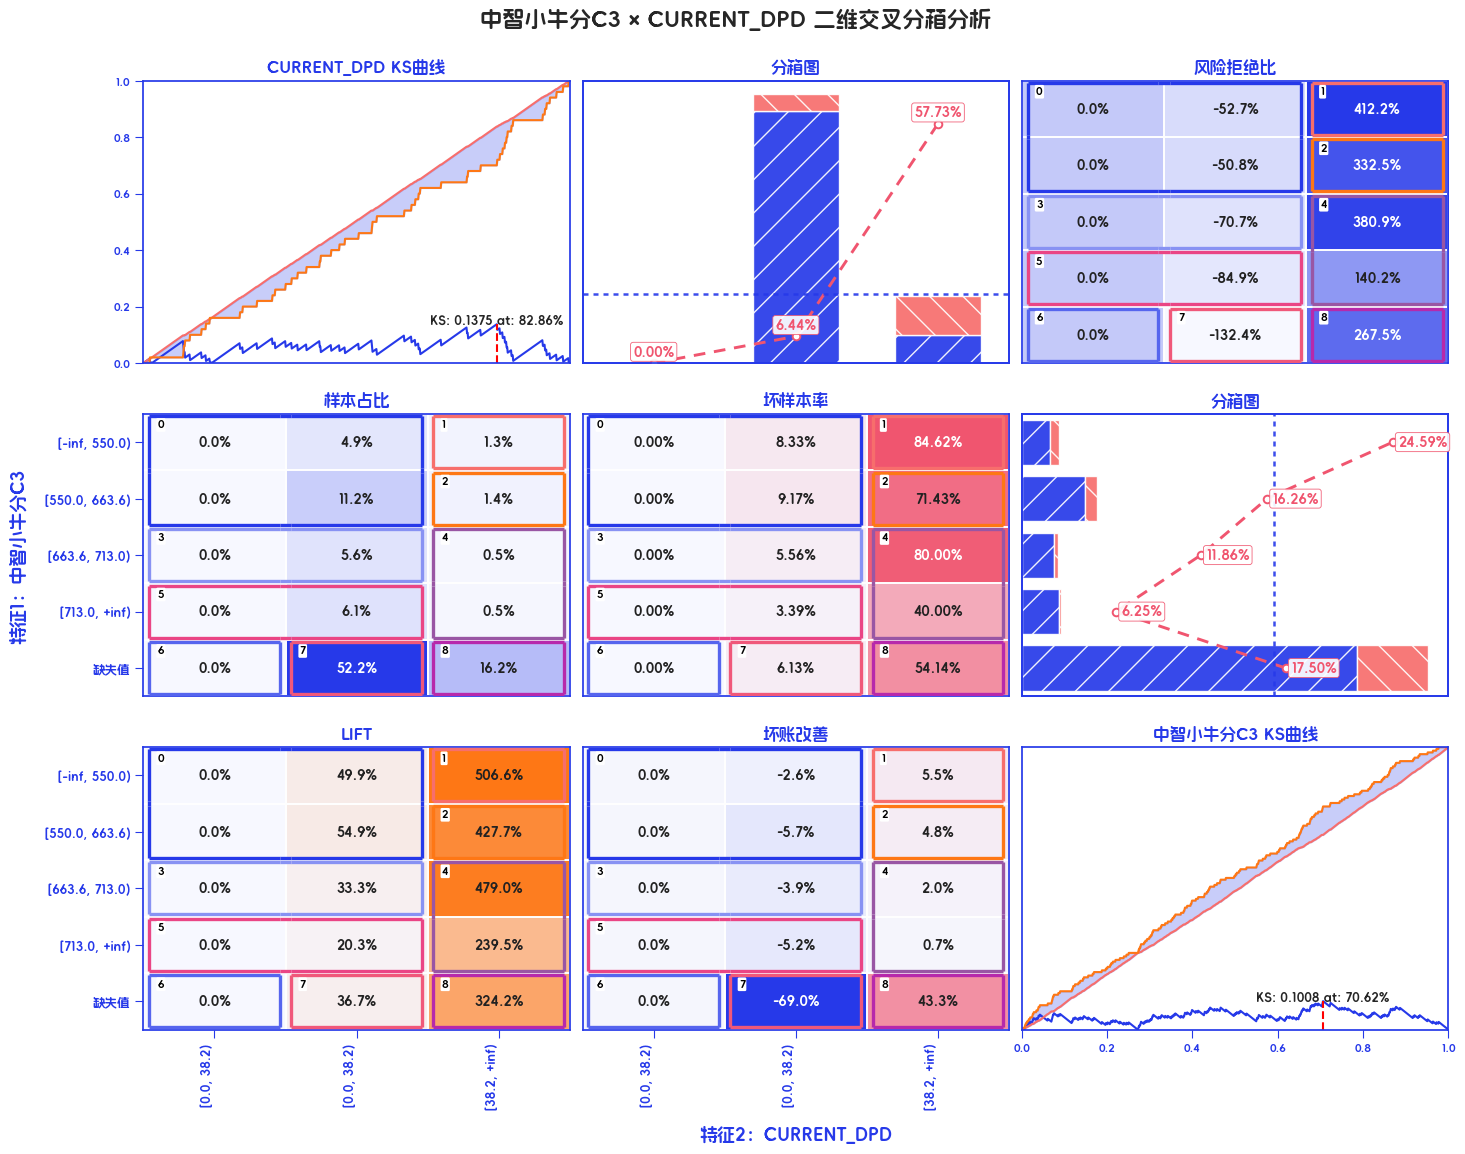

In [10]:
from hscredit import bin_2d_plot

# 方式1：直接传入上文已拟合的 OptimalBinning2D
# 图中：上方为特征2分箱图（纵向），右下为特征1分箱图（横向），
#       两条 KS 曲线，其余 5 格为交叉指标热力图（均为百分数）
fig = bin_2d_plot(binner)
plt.show()

In [11]:
binner

,target,'target'
,max_n_bins,5
,min_bin_size,0.02
,method,'quantile'
,monotonic,False
,max_n_bins_2d,6
,max_n_bins_x,None
,min_bin_size_x,None
,method_x,None
,monotonic_x,'auto'
,user_splits_x,None


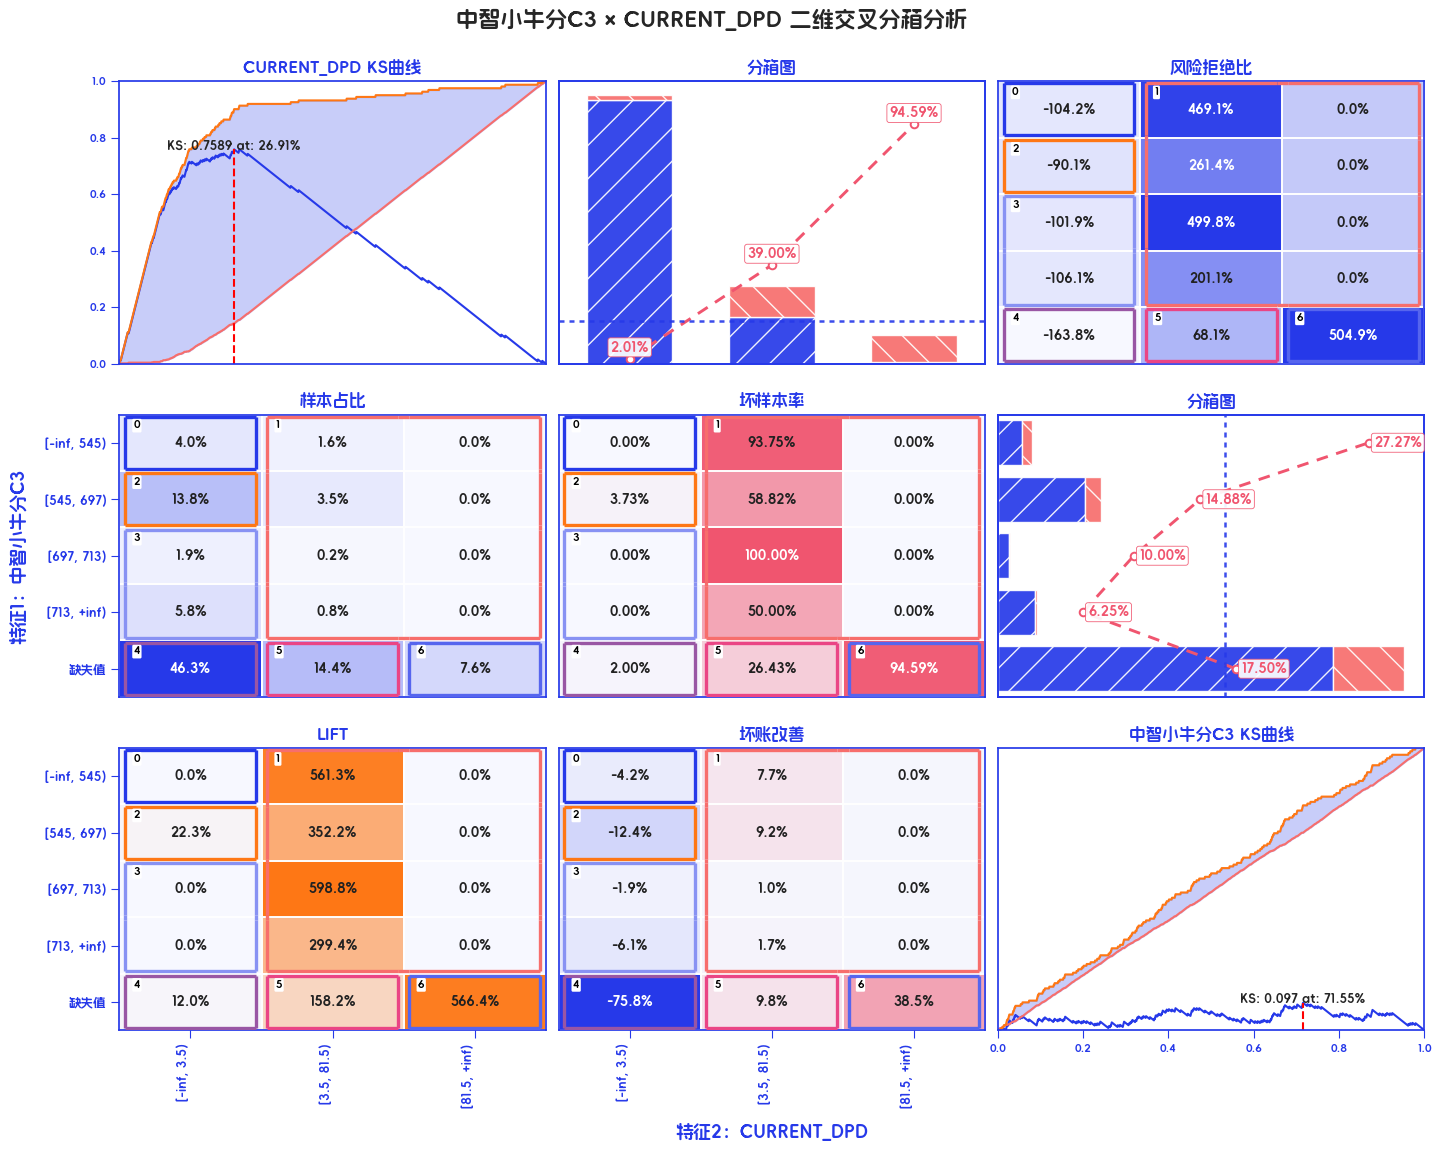

In [12]:
# 方式2：传入原始数据，内部自动构建并拟合 OptimalBinning2D
# 可通过 method / max_n_bins 等参数控制分箱方式
fig = bin_2d_plot(
    df,
    features=[feat1, feat2],
    target=target,
    method='best_iv',
    max_n_bins=4,
)
plt.show()

## 7. Transform 转换

`transform` 将两个原始特征联合转换为一个交互特征列，支持最终箱索引、二维区间标签、WOE 和坏样本率。

In [13]:
# 最终二维分箱索引（单列交互特征）
X_binned = binner.transform(df[[feat1, feat2]], metric='indices')
bin_col = X_binned.columns[0]
valid_mask = df[feat1].notna() & df[feat2].notna()
print('完整二维分箱索引分布（-1 表示缺失箱）:')
print(X_binned[bin_col].value_counts().sort_index())
print('\n非缺失样本转换结果:')
display(pd.concat([df.loc[valid_mask, [feat1, feat2]], X_binned.loc[valid_mask]], axis=1).head())
print(f"输出列: {X_binned.columns.tolist()}")

完整二维分箱索引分布（-1 表示缺失箱）:
中智小牛分C3XCURRENT_DPD
0    157
1     13
2     14
3     54
4     10
5     59
7    506
8    157
Name: count, dtype: int64

非缺失样本转换结果:


,中智小牛分C3,CURRENT_DPD,中智小牛分C3XCURRENT_DPD
662,556.0000,78,2
663,580.0000,50,2
664,608.0000,55,2
665,768.0000,0,5
666,738.0000,0,5


输出列: ['中智小牛分C3XCURRENT_DPD']


In [14]:
# WOE 与坏样本率转换
X_bins = binner.transform(df[[feat1, feat2]], metric='bins')
X_woe = binner.transform(df[[feat1, feat2]], metric='woe')
X_event_rate = binner.transform(df[[feat1, feat2]], metric='event_rate')
display(pd.concat([
    X_bins.head().add_suffix('_分箱'),
    X_woe.head().add_suffix('_WOE'),
    X_event_rate.head().add_suffix('_坏样本率'),
], axis=1))

,中智小牛分C3XCURRENT_DPD_分箱,中智小牛分C3XCURRENT_DPD_WOE,中智小牛分C3XCURRENT_DPD_坏样本率
0,"缺失值 × [0.0, 38.2)",-1.1224,0.0613
1,"缺失值 × [0.0, 38.2)",-1.1224,0.0613
2,"缺失值 × [0.0, 38.2)",-1.1224,0.0613
3,"缺失值 × [0.0, 38.2)",-1.1224,0.0613
4,"缺失值 × [0.0, 38.2)",-1.1224,0.0613


## 8. 获取最终分箱指标矩阵

各指标会按最终二维分箱回填到初始网格；属于同一最终箱的格子具有相同的坏样本率、WOE、IV 和 LIFT。

In [15]:
# 获取坏样本率矩阵
bad_rate_matrix = binner.get_bad_rate_matrix()
print("坏样本率矩阵:")
print(bad_rate_matrix.round(3))

坏样本率矩阵:
                [0.0, 38.2)  [0.0, 38.2)  [38.2, +inf)
[-inf, 550.0)        0.0890       0.0890        0.8460
[550.0, 663.6)       0.0890       0.0890        0.7140
[663.6, 713.0)       0.0560       0.0560        0.6000
[713.0, +inf)        0.0340       0.0340        0.6000


In [16]:
# 获取 IV 矩阵
iv_matrix = binner.get_iv_matrix()
print("IV矩阵:")
print(iv_matrix.round(4))

IV矩阵:
                [0.0, 38.2)  [0.0, 38.2)  [38.2, +inf)
[-inf, 550.0)        0.0649       0.0649        0.2167
[550.0, 663.6)       0.0649       0.0649        0.1433
[663.6, 713.0)       0.0547       0.0547        0.0646
[713.0, +inf)        0.1014       0.1014        0.0646


## 9. 自定义分箱规则

特征1默认切分点: [550.  663.6 713. ]
特征2默认切分点: [ 0.  38.2]


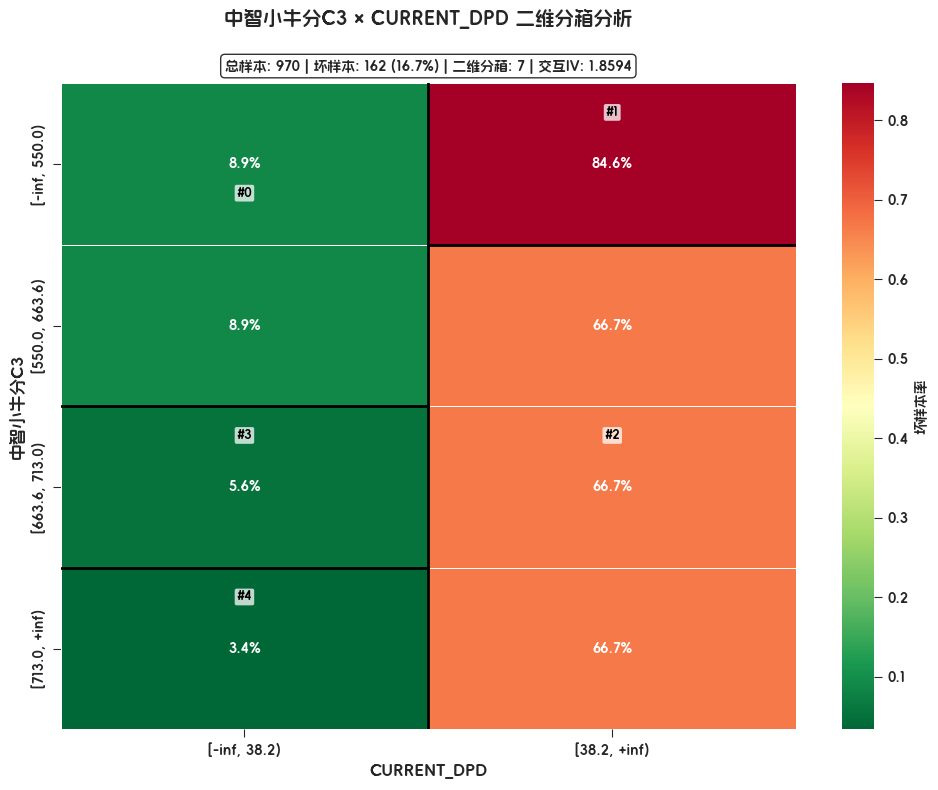

In [17]:
# 用户自定义切分点（基于默认分箱的切分点微调）
default_splits_x = binner.splits_x_
default_splits_y = binner.splits_y_

print(f"特征1默认切分点: {default_splits_x}")
print(f"特征2默认切分点: {default_splits_y}")

# 使用自定义切分点创建新的分箱器
binner_custom = OptimalBinning2D(
    user_splits_x=default_splits_x,
    user_splits_y=default_splits_y
)
binner_custom.fit(df, y=df[target], features=[feat1, feat2])

fig = binner_custom.plot(metric='bad_rate', figsize=(10, 8))
plt.show()

## 10. 批量特征分箱

In [18]:
# 对多对特征进行批量二维分箱分析
selected_pairs = [[features[0], features[1]]]
if len(features) > 2:
    selected_pairs.append([features[0], features[2]])

results = []
for feat_pair in selected_pairs:
    try:
        b = OptimalBinning2D(max_n_bins=4, max_n_bins_2d=5)
        b.fit(df, y=df[target], features=feat_pair)
        results.append({
            '特征1': feat_pair[0],
            '特征2': feat_pair[1],
            '预分箱网格': f"{b.n_bins_x_}×{b.n_bins_y_}",
            '最终二维分箱数': b.n_bins_2d_,
            '交互IV': round(b.iv_interaction_, 4),
        })
    except Exception as e:
        results.append({'特征1': feat_pair[0], '特征2': feat_pair[1], '错误': str(e)})

display(pd.DataFrame(results))

,特征1,特征2,预分箱网格,最终二维分箱数,交互IV
0,放款金额,CURRENT_DPD,4×3,5,3.0259
1,放款金额,中智小牛分C3,4×4,9,0.3990


---

## 总结

`OptimalBinning2D` 的处理流程：

1. 分别对两个特征进行一维预分箱，并映射为二维网格索引
2. 在最小样本量、最大二维箱数和轴向单调性约束下合并相邻格子
3. 通过 `get_bin_table()` 获取使用 hscredit 统一指标口径的最终二维分箱表
4. 通过 `plot()` 查看最终箱的指标色块、编号和合并边界
5. 通过 `transform()` 将两个原始特征转换为单个二维分箱索引、标签、WOE 或坏样本率

`get_cross_table()` 和矩阵方法保留初始网格视角，便于诊断每个最终二维箱由哪些相邻格子组成。